# GPT-5.2

In [1]:
GROUP_NAME = "gpt-5.2-gaze2"
RESULT_PATH = "../output/result_1771518084_20251124F_20260220F_20251123_20251124.csv"

## Setup

In [2]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance", "tidyr", "car")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("ggeffects", "strengejacke/ggeffects")

utils:::print.sessionInfo(sessionInfo()[-c(10,12,13)])

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.2

Matrix products: default


locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        car_3.1-3              carData_3.0-5         
 [4] tidyr_1.3.1            performance_0.14.0     parameters_0.28.3     
 [7] dplyr_1.1.4            ggplot2_3.5.1          marginaleffects_0.25.1
[10] readr_2.1.5            lme4_1.1-35.5          Matrix_1.6-5          


In [3]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor()))
df <- df[df$Group == GROUP_NAME, ]
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

## On Stimuli B (Hypothesis-Driven)

In [130]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_unnatural <- df_B %>%
  filter(Condition %in% c("congruent", "incongruent")) %>% 
  mutate(offset_wrongness_head = qlogis(ExpectedDistToHeadTarget / MaxDistToHeadTarget),)
df_replicate <- df_B[df_B$Condition != "incongruent", ]

In [131]:
ggplot(df_unnatural, aes(x = n_candidates)) +
    geom_histogram(binwidth = 1, fill = "lightblue") +
    theme_minimal() +
    labs(
        title = "Distribution of Number of Objects",
        x = "Number of Objects",
        y = "Count"
    )

### Replicating the Proximity effect and the (lack of) View effect

In [ ]:
m_effects1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
m_effects2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
m_effects3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
m_effects4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
isSingular(m_effects1)
isSingular(m_effects2)
isSingular(m_effects3)
isSingular(m_effects4)
compare_performance(m_effects1, m_effects2, m_effects3, m_effects4, rank = TRUE)

[1] TRUE

[1] TRUE

[1] TRUE

[1] FALSE

Some of the nested models seem to be identical and probably only vary in
  their random effects.



Random effect variances not available. Returned R2 does not account for random effects.
Random effect variances not available. Returned R2 does not account for random effects.
Random effect variances not available. Returned R2 does not account for random effects.


Following indices with missing values are not used for ranking:
  R2_conditional, Sigma, Log_loss, ICC



Name,Model,R2_conditional,R2_marginal,RMSE,Sigma,Log_loss,ICC,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects4,glmerMod,0.7946031,0.08324889,0.2227997,1,NA,0.7759513,0.53444666,0.53587420,9.808180e-01,0.6580757
m_effects3,glmerMod,NA,0.28841323,0.2227997,1,NA,NA,0.19661194,0.19616511,9.544572e-03,0.5093128
m_effects1,glmerMod,NA,0.28841333,0.2227997,1,NA,NA,0.07232949,0.07179559,9.288049e-05,0.3680089
m_effects2,glmerMod,NA,0.28841475,0.2227997,1,NA,NA,0.19661192,0.19616509,9.544571e-03,0.3093142


In [ ]:
m_effects_c <- m_effects4

In [ ]:
m_effects <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
anova(m_effects, m_effects_c)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects,7,12737.75,12788.6,-6361.875,12723.75,NA,NA,NA
m_effects_c,25,12760.97,12942.6,-6355.487,12710.97,12.77447,18,0.8047929


In [ ]:
avg_slopes(m_effects_c, variables = "Proximity")
avg_slopes(m_effects_c, variables = "n_candidates")
avg_comparisons(m_effects_c, variables = "Angle")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.07855492,0.01685372,4.660984,3.14701e-06,18.27759,0.04552224,0.1115876


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,0.03667691,0.01638064,2.23904,0.02515332,5.313107,0.004571443,0.06878238


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.1406328,0.03368814,4.174548,2.985782e-05,15.03153,0.07460522,0.2066603
Angle,right - front,0.1184981,0.03365949,3.520496,4.307399e-04,11.18090,0.05252673,0.1844695


In [ ]:
### Report
summary(m_effects)
Anova(m_effects, type = 3)
vc_list <- lapply(VarCorr(m_effects), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(m_effects)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

# The below code is for generating the table in the paper.
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

#actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
#actory_est <- res[res$term == actory_term_name, "Estimate"]
#actory_se <- res[res$term == actory_term_name, "Std. Error"]
#actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
#actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("View=left", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("View=right", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size))

    #c("ActorY", "b", sprintf("%.7f", actory_est)),
    #c("", "SE", sprintf("%.7f", actory_se)),
    #c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    #c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    Condition + offset(offset_wrongness) + (1 | Stimulus_ID)
   Data: df_replicate
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
  12737.7   12788.6   -6361.9   12723.7     10553 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.8939 -0.3373 -0.1452  0.2223  4.9683 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 6.335    2.517   
Number of obs: 10560, groups:  Stimulus_ID, 660

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -1.49251    0.20465  -7.293 3.03e-13 ***
scale(Proximity, scale = FALSE)     0.66099    0.12691   5.208 1.91e-07 ***
Angleleft                   

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),53.18615978,1,3.033889e-13
"scale(Proximity, scale = FALSE)",27.12628932,1,1.905884e-07
Angle,19.71336637,2,5.239585e-05
"scale(n_candidates, scale = FALSE)",5.37368894,1,2.044270e-02
Condition,0.04762661,1,8.272459e-01


term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.49251367,0.2046534,-7.2928842,0.0000000000003033889,-1.89363437,-1.0913930,3.102442,-0.48107706
"scale(Proximity, scale = FALSE)",0.66098562,0.1269103,5.2082904,0.0000001905884365537,0.41224146,0.9097298,3.102442,0.21305334
Angleleft,1.05969591,0.2518873,4.2070243,0.0000258755374501016,0.56599684,1.5533950,3.102442,0.34156832
Angleright,0.83585071,0.2530758,3.3027678,0.0009573561481649657,0.33982208,1.3318793,3.102442,0.26941703
"scale(n_candidates, scale = FALSE)",0.28122153,0.1213144,2.3181219,0.0204426994355160069,0.04344533,0.5189977,3.102442,0.09064522
Conditioncongruent,0.04510907,0.2066993,0.2182352,0.8272458522491148436,-0.36002158,0.4502397,3.102442,0.01453986


6.3352781
NA
NA
3.1024420
-1.4925137
0.2046534
1.0596959
0.2518873
0.0000259
0.3415683
0.8358507
0.2530758
0.0009574
0.2694170
0.6609856
0.1269103
0.0000002
0.2130533
0.2812215
0.1213144
0.0204427
0.0906452


### Test 2.1: Choose head targets more↑ often than gaze targets (when they differ).
Take results in the Incongruent Condition with #Objects greater than 2 and the responded object being either GazeTarget or HeadTarget. Fit a model with “IsHeadTarget ~ 1 + (1 | Objects) + (1 | StimulusID) + (1 | PromptID)” for each VLM. A significant positive intercept indicates a positive answer.

In [154]:
df_test21 <- df_B %>%
  filter(
    Condition == "incongruent",
    n_candidates > 2,
    (Choice == HeadTarget | Choice == label) # Keep only trials where the choice was one of the two cues
  )

mean(df_test21$IsHeadTarget)
m_head_bias <- glmer(
  as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID),
  data = df_test21, 
  family = binomial,
  control = strict_control
)
summary(m_head_bias)

[1] 0.5643031

[1] 1

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID)
   Data: df_test21
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
   4081.4    4094.7   -2038.7    4077.4      5752 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6595 -0.1525  0.1166  0.2733  3.5160 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 16.53    4.065   
Number of obs: 5754, groups:  Stimulus_ID, 526

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.7483     0.1908   3.922 8.77e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [149]:
1 / (1 + exp(-0.7417))

[1] 0.6773675

In [134]:
stimulus_means <- df_test21 %>%
  group_by(Stimulus_ID) %>%
  summarize(n = n())
table(stimulus_means$n)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16 
 36  15  28  19  13  23  12  13  24  15  20  32  44  28  61 143 

In [148]:
avg_predictions(m_head_bias, by = c("Proximity_c"))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Proximity_c,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-1.005882353,0.6197698,0.02409592,25.72095,6.815567e-146,482.2327,0.5725427,0.6669970,Inf
-0.005882353,0.5538465,0.01650345,33.55944,6.557096e-247,817.8032,0.5215003,0.5861926,Inf
0.994117647,0.5185074,0.02425223,21.37978,2.060887e-101,334.4715,0.4709739,0.5660409,Inf


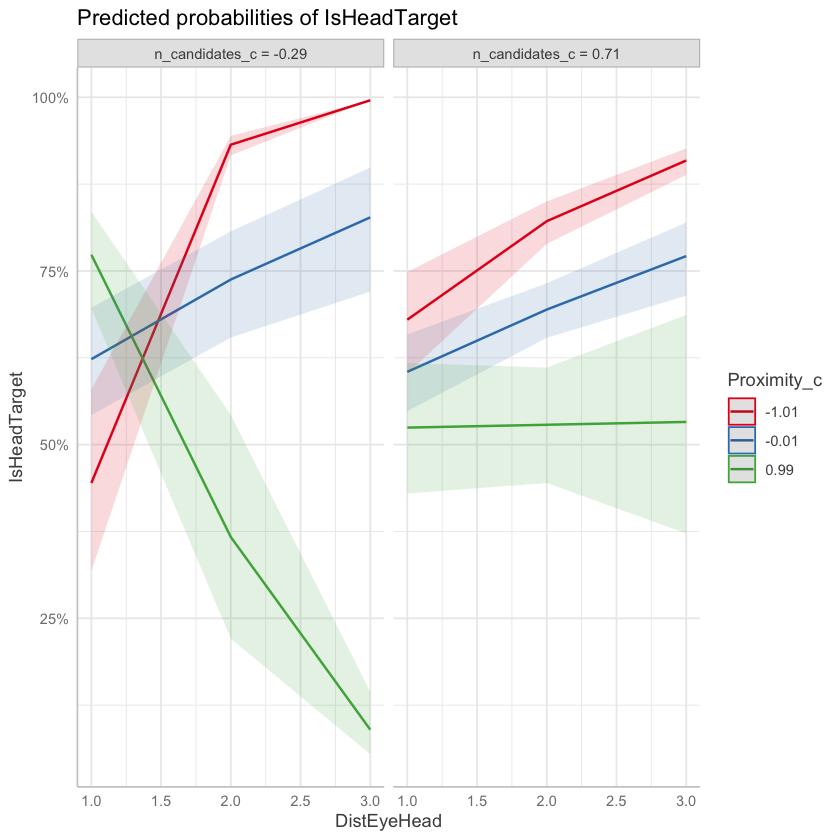

In [ ]:
plot(ggpredict(
  m_head_bias, 
  terms = c("DistEyeHead [all]", "Proximity_c [all]", "n_candidates_c [all]")
))

### Test 2.2: When head orientation is fixed but only eye appearance varies, responses stay the same much more often than chance?
Take results in the Congruent and Incongruent Conditions. Fix a combination of (#Objects, Objects, Proximity, View, HeadTarget, PromptID), vary only GazeTarget (2-4 levels). Calculate the number of combinations where the Choice stays the same. Compare the rate of such to chance using a directional one-sample t-test. Rejecting the null hypothesis indicates a positive answer.

In [153]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1 & first(IsHeadTarget) == TRUE, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 0)
  )

cat("Actual Stability Rate (choosing headtarget): ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate (choosing headtarget):  0.2892267 
Random Chance Baseline: 0.09560342 



	One Sample t-test

data:  diff_scores
t = 33.296, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.1840564       Inf
sample estimates:
mean of x 
0.1936233 


In [152]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 1)
  )

cat("Actual Stability Rate: ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate:  0.580518 
Random Chance Baseline: 0.203735 



	One Sample t-test

data:  diff_scores
t = 58.566, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.3661991       Inf
sample estimates:
mean of x 
 0.376783 


### Test 2.3: Performance when the HeadTarget = the GazeTarget is much higher↑ than when they differ?
Take results in the Congruent and Incongruent Conditions. Fit “IsCorrect ~ Proximity * View * #Object  * Condition + (1|Random Effects)” with offset being the chance accuracy. If the marginal prediction of Condition indicates that accuracy is higher in the congruent condition than in the incongruent condition, then this claim is supported.

In [ ]:
mean(df_B[df_B$Condition == "congruent", ]$Accuracy)
mean(df_B[df_B$Condition == "incongruent", ]$Accuracy)

[1] 0.4474085

[1] 0.2895536

In [ ]:
model_cond <- glmer(Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_accuracy) + (1|Stimulus_ID) + (1|Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
isSingular(model_cond)

[1] FALSE

In [ ]:
summary(model_cond)


Correlation matrix not shown by default, as p = 24 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition +  
    offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID)
   Data: df_unnatural
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
  11600.4   11800.8   -5774.2   11548.4     16422 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0321 -0.2642 -0.1008  0.1770  4.0447 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 12.44419 3.52763 
 Prompt_ID   (Intercept)  0.00268 0.05177 
Number of obs: 16448, groups:  Stimulus_ID, 1028; Prompt_ID, 16

Fixed effects:
                                                            Estimate Std. Error
(Intercept)                                                 0.498234   0.363398
Proximity_c                                                -0.618563   0.448223
Angleleft            

In [ ]:
avg_predictions(model_cond, variables = "Condition")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Condition,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
congruent,0.4215494,0.02127180,19.81729,2.111804e-87,287.9293,0.3798574,0.4632413,Inf
incongruent,0.2928632,0.01360985,21.51847,1.045643e-102,338.7723,0.2661884,0.3195380,Inf


In [ ]:
avg_predictions(model_cond, variables = "Condition", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(incongruent) - (congruent),-0.1286862,0.02519746,-5.107108,3.271265e-07,21.54365,-0.1780723,-0.07930005,Inf


### Test 2.4: Fix the GazeTarget, as the HeadTarget moves farther away from the GazeTarget, their responses also move farther away from the GazeTarget?

Here, the distance is one plus the number of objects between them.
Take results in the Congruent and Incongruent Conditions. Fit “cbind(Wrongness, MaxWrongness - Wrongness) ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects)” with offset again being the chance baseline. If the marginal slope indicates that as DistEyeHead increases, the relative Wrongness also increases, then the answer is yes.

In [ ]:
m_dist1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_dist2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
m_dist3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_dist4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_unnatural, family = binomial, control = strict_control)
    
isSingular(m_dist1)
isSingular(m_dist2)
isSingular(m_dist3)
isSingular(m_dist4)
compare_performance(m_dist1, m_dist2, m_dist3, m_dist4, rank = TRUE)

[1] TRUE

[1] TRUE

[1] FALSE

[1] FALSE

Some of the nested models seem to be identical and probably only vary in
  their random effects.



Random effect variances not available. Returned R2 does not account for random effects.
Random effect variances not available. Returned R2 does not account for random effects.


Following indices with missing values are not used for ranking:
  R2_conditional, Sigma, Log_loss, ICC



Name,Model,R2_conditional,R2_marginal,RMSE,Sigma,Log_loss,ICC,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_dist4,glmerMod,0.7717196,0.07711469,0.2284638,1,NA,0.7526449,0.4273458,0.4282785,0.9775380372,0.8000000
m_dist2,glmerMod,NA,0.25250876,0.2284638,1,NA,NA,0.1572108,0.1570554,0.0076220994,0.4581275
m_dist3,glmerMod,0.7718263,0.07745042,0.2284650,1,NA,0.7526705,0.3037138,0.3034136,0.0147250485,0.2462667
m_dist1,glmerMod,NA,0.25341718,0.2284650,1,NA,NA,0.1117296,0.1112524,0.0001148149,0.2000000


In [ ]:
anova(m_dist3, m_dist4)
m_dist_c <- m_dist3

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_dist4,25,22771.44,22964.14,-11360.72,22721.44,NA,NA,NA
m_dist3,26,22772.12,22972.53,-11360.06,22720.12,1.316985,1,0.2511339


In [ ]:
avg_slopes(m_dist_c, variables = "DistEyeHead")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.09910867,0.01322478,7.494165,6.672169e-14,43.76884,0.07318858,0.1250288


In [155]:
exp(0.09910867)

[1] 1.104186

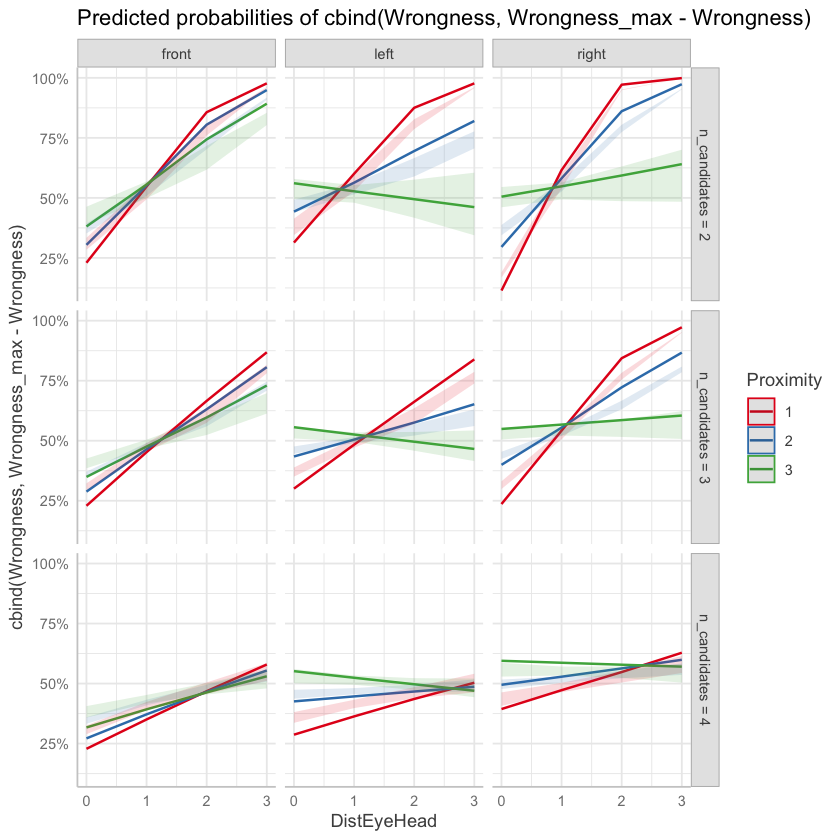

In [ ]:
plot(ggpredict(
  m_dist_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]"),
  bias_correction = TRUE
))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


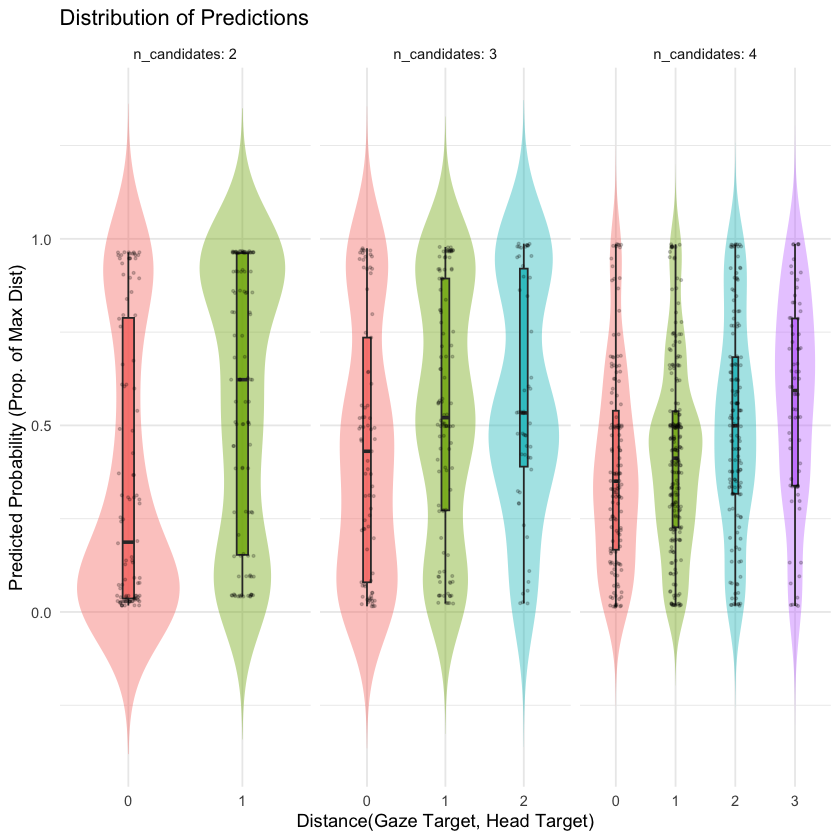

In [ ]:
valid_grid <- df_unnatural %>%
    distinct(Proximity, Angle, DistEyeHead, n_candidates, offset_wrongness, Stimulus_ID, Candidates)
preds <- predictions(m_dist_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)

ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


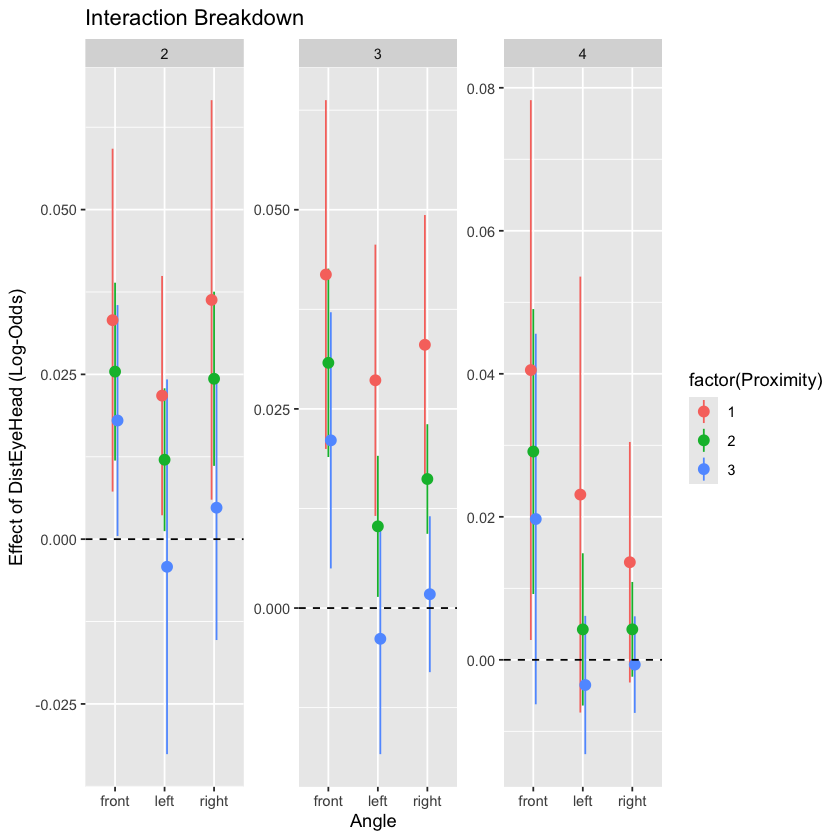

In [ ]:
plot_slopes(
  m_dist_c,
  variables = "DistEyeHead",
  condition = c("Angle", "Proximity", "n_candidates") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of DistEyeHead (Log-Odds)", title = "Interaction Breakdown")

In [ ]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Proximity")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,1,0.17163805,0.02174558,7.893009,2.949858e-15,48.268276,0.129017497,0.21425859
DistEyeHead,dY/dX,2,0.09442985,0.01342333,7.034757,1.996088e-12,38.865962,0.068120608,0.12073909
DistEyeHead,dY/dX,3,0.03272974,0.01981832,1.651489,9.863882e-02,3.341701,-0.006113463,0.07157294


In [ ]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Angle", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),-0.11834631,0.03446003,-3.434306,0.0005940728,10.717073,-0.1858867,-0.05080588
(right) - (front),-0.08127382,0.03359704,-2.419077,0.0155599439,6.006019,-0.1471228,-0.01542484
(right) - (left),0.03707249,0.02878537,1.287894,0.1977830270,2.338009,-0.0193458,0.09349078


### Test 3: Fix the HeadTarget. As the GazeTarget moves farther away from the HeadTarget, do their responses move farther away from the HeadTarget?
Take results in the Congruent and Incongruent Conditions. Fit “cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ Proximity * Angle * #Objects * DistEyeHead + (1|Random Effects)” with offset being the chance baseline logit(ExpectedDistToHeadTarget / MaxDistToHeadTarget). If the marginal slope indicates that as DistEyeHead increases, the relative DistToHeadTarget also increases, then the answer is yes.

In [157]:
m_head_c <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1|Stimulus_ID) + (1|Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)

In [162]:
avg_slopes(m_head_c, variables = "DistEyeHead", newdata = subset(Proximity==1))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.0502912,0.02290273,2.19586,0.02810194,5.153186,0.005402671,0.09517973


In [163]:
exp(0.0502912)

[1] 1.051577

In [158]:
avg_slopes(m_head_c, variables = "DistEyeHead")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.02608995,0.01354399,1.926312,0.05406547,4.209149,-0.0004557866,0.05263568


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


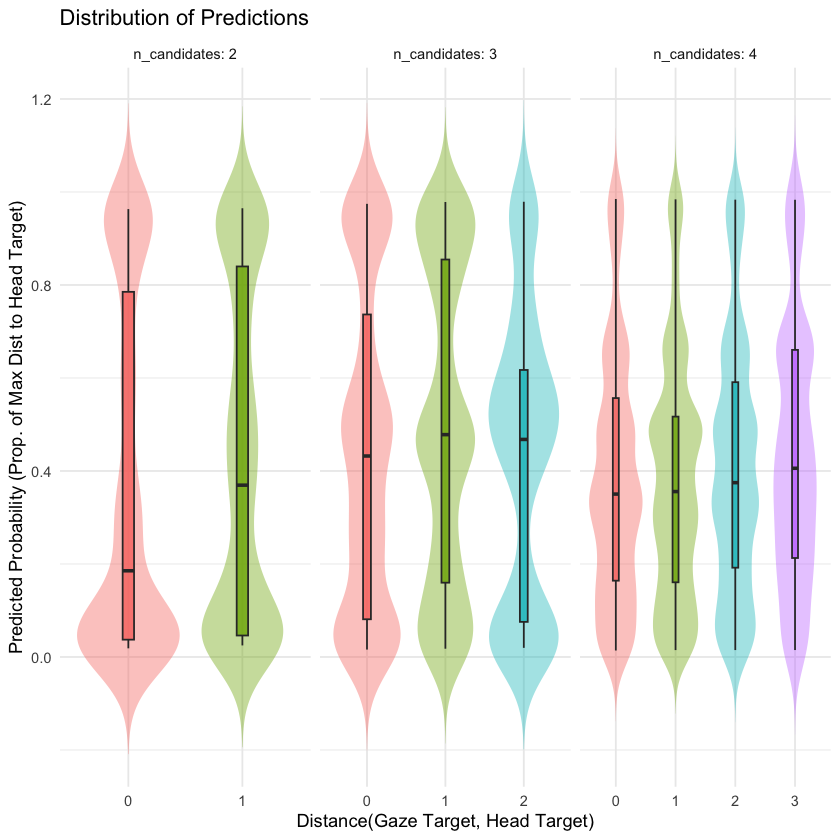

In [168]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_wrongness_head, Stimulus_ID, Prompt_ID, Candidates)
preds <- predictions(m_head_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
#  geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist to Head Target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

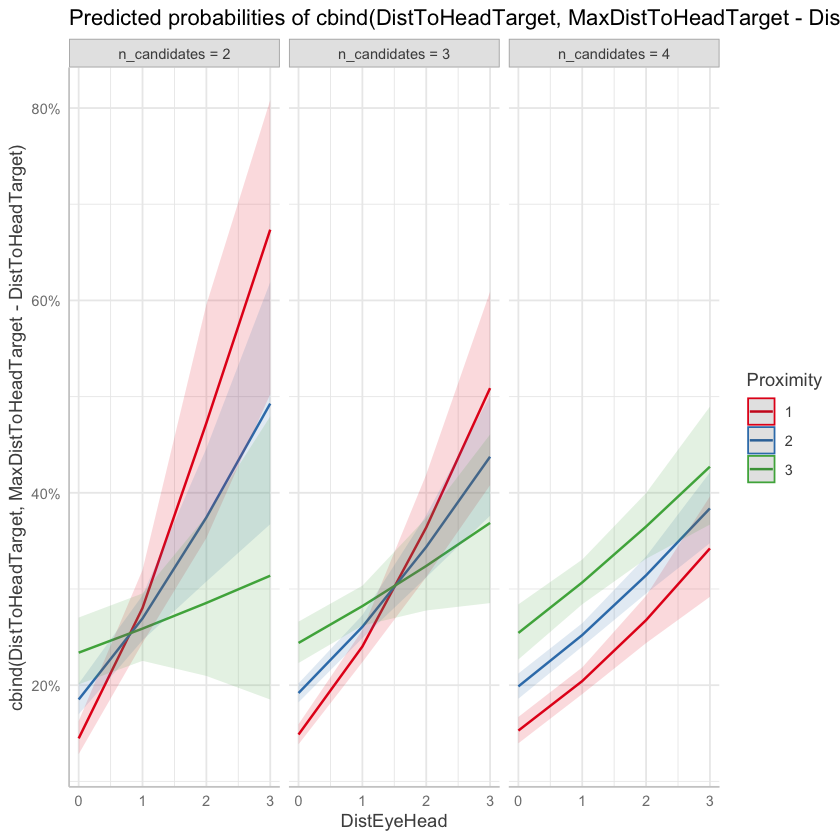

In [169]:
plot(ggpredict(
  m_head_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "n_candidates [all]")
))

### Test 4: How exactly does Frequency(response=head target) correlate with distance(head target, gaze target)? 
This will distinguish between Possibilities 4 & 5. Possibility 4 predicts that Frequency(response=head target) correlates negatively with distance(head target, gaze target), while Possibility 5 predicts that Frequency(response=head target) jumps down only when distance(head target, gaze target) goes from 0 to 1, but stays the same after that. If the relation turns out not to be a negative correlation, then these two explanations are incomplete. 

Take results in the Congruent and Incongruent Conditions with #Objects greater than 2. Fit “IsHeadTarget ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects).” Here, DistEyeHead is treated as categorical. Separately looking at #Object=3 and 4, the marginal means of IsHeadTarget for DistEyeHead=1 and 2 (or 1, 2, and 3 for #Object=4) are not significantly different from each other, but are all significantly lower than when DistEyeHead=0, then Possibility 5 is supported. Otherwise, if the marginal mean in general decreases, then Possibility 4 is supported.

In [ ]:
m_3obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural[df_unnatural$n_candidates == 3, ], family = binomial, control = strict_control)

In [ ]:
m_4obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural[df_unnatural$n_candidates == 4, ], family = binomial, control = strict_control)

In [ ]:
avg_predictions(m_3obj, variables = "DistEyeHead", hypothesis = ~ pairwise)
avg_predictions(m_4obj, variables = "DistEyeHead", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),-0.009156535,0.05738402,-0.1595659,0.8732230,0.1955779,-0.12162715,0.1033141,Inf
(2) - (0),0.024847759,0.06732567,0.3690681,0.7120769,0.4898949,-0.10710813,0.1568036,Inf
(2) - (1),0.034004294,0.06396725,0.5315891,0.5950106,0.7490126,-0.09136922,0.1593778,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),0.01034353,0.04000174,0.2585770,0.79596167,0.3292291,-0.06805844,0.088745494,Inf
(2) - (0),-0.02315873,0.04363744,-0.5307079,0.59562123,0.7475329,-0.10868655,0.062369082,Inf
(3) - (0),-0.06881058,0.04788865,-1.4368870,0.15075010,2.7297692,-0.16267060,0.025049449,Inf
(2) - (1),-0.03350226,0.03966609,-0.8446071,0.39833026,1.3279630,-0.11124637,0.044241850,Inf
(3) - (1),-0.07915411,0.04431272,-1.7862615,0.07405693,3.7552214,-0.16600544,0.007697231,Inf
(3) - (2),-0.04565184,0.04761985,-0.9586726,0.33772373,1.5660846,-0.13898503,0.047681348,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


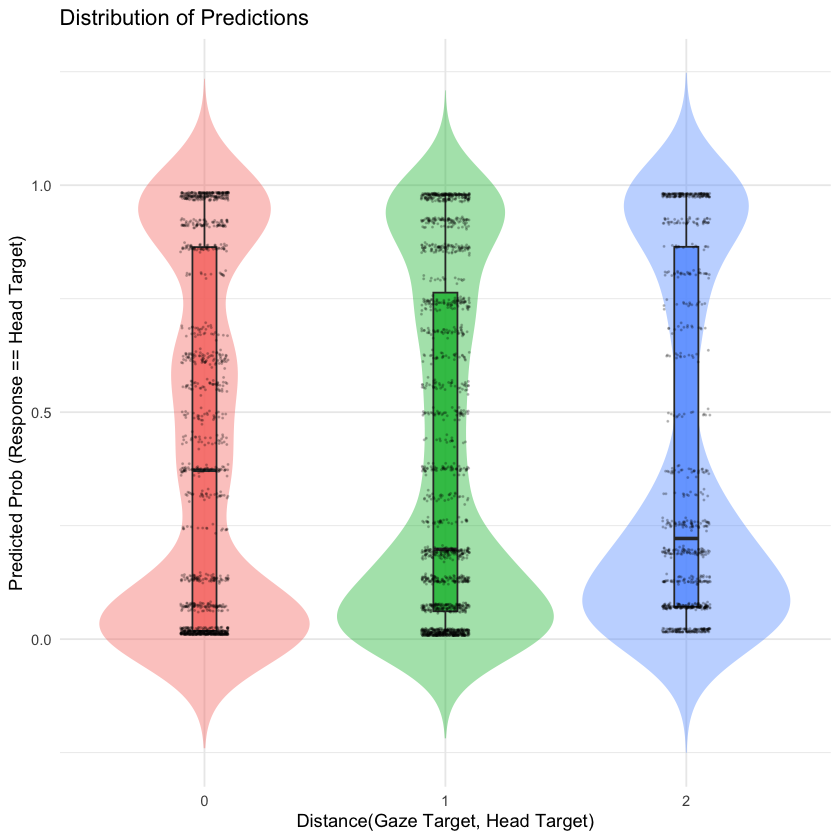

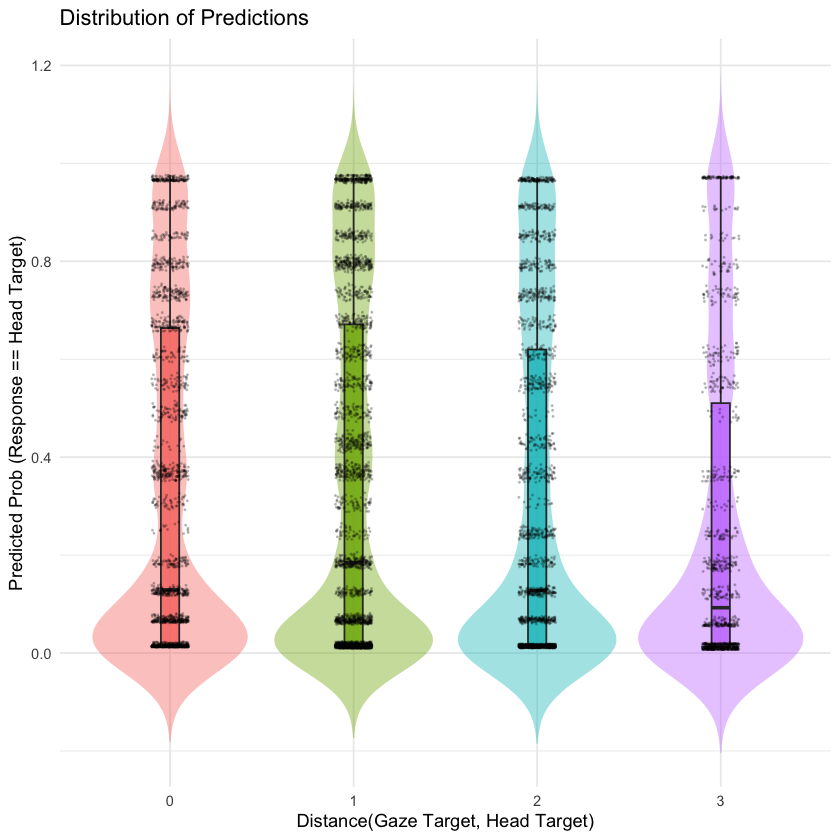

In [165]:
plot_head_preds <- function(model, data, x_var = "DistEyeHead", facet_var = NULL) {
  
  # 1. Define the columns we absolutely need for the prediction grid
  #    (Predictors + Random Effect Group + Offset)
  needed_cols <- c(x_var, "Candidates", "Proximity", "Angle", "offset_accuracy", "Stimulus_ID", "Prompt_ID")
  if (!is.null(facet_var)) needed_cols <- c(needed_cols, facet_var)
  
  # 2. Create the valid_grid
  #    We use distinct() to avoid predicting on 20,000 rows if we only need
  #    unique condition+candidate combinations.
  valid_grid <- data %>%
    select(all_of(intersect(needed_cols, names(data)))) %>%
    distinct()
  
  # 3. Generate Predictions
  #    type="response" ensures we get probabilities (0-1)
  preds <- predictions(model, newdata = valid_grid, type = "response")
  
  # 4. Prepare for plotting
  #    Convert x_var to factor so violin plots work properly
  preds[[x_var]] <- as.factor(preds[[x_var]])
  
  # 5. Build the Plot
  p <- ggplot(preds, aes(x = .data[[x_var]], y = estimate, fill = .data[[x_var]])) +
    # The Violin: Density across items
    geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
    
    # The Boxplot: Summary stats
    geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
    
    # Jitter: Individual item points
    geom_jitter(width = 0.1, alpha = 0.2, size = 0.2) +
    
    # Labels
    labs(
      x = "Distance(Gaze Target, Head Target)",
      y = "Predicted Prob (Response == Head Target)",
      title = "Distribution of Predictions"
    ) +
    theme_minimal() +
    theme(legend.position = "none")
  
  # 6. Add Faceting conditionally
  if (!is.null(facet_var)) {
    p <- p + facet_wrap(as.formula(paste("~", facet_var)), 
                        labeller = label_both, 
                        scales = "free_x")
  }
  
  return(p)
}

plot_head_preds(
  model = m_3obj, 
  data = df_unnatural[df_unnatural$n_candidates == 3, ]
)
plot_head_preds(
  model = m_4obj, 
  data = df_unnatural[df_unnatural$n_candidates == 4, ]
)

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.

Ignoring unknown labels:
• linetype : "DistEyeHead"
• shape : "DistEyeHead"


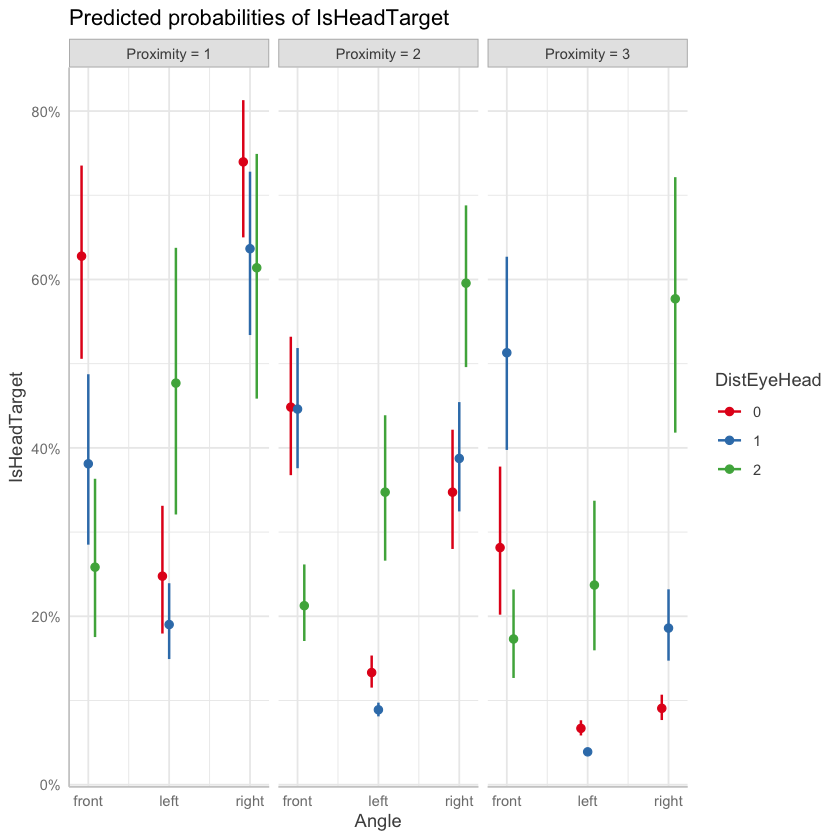

In [ ]:
plot(ggpredict(
  m_3obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

Ignoring unknown labels:
• linetype : "DistEyeHead"
• shape : "DistEyeHead"


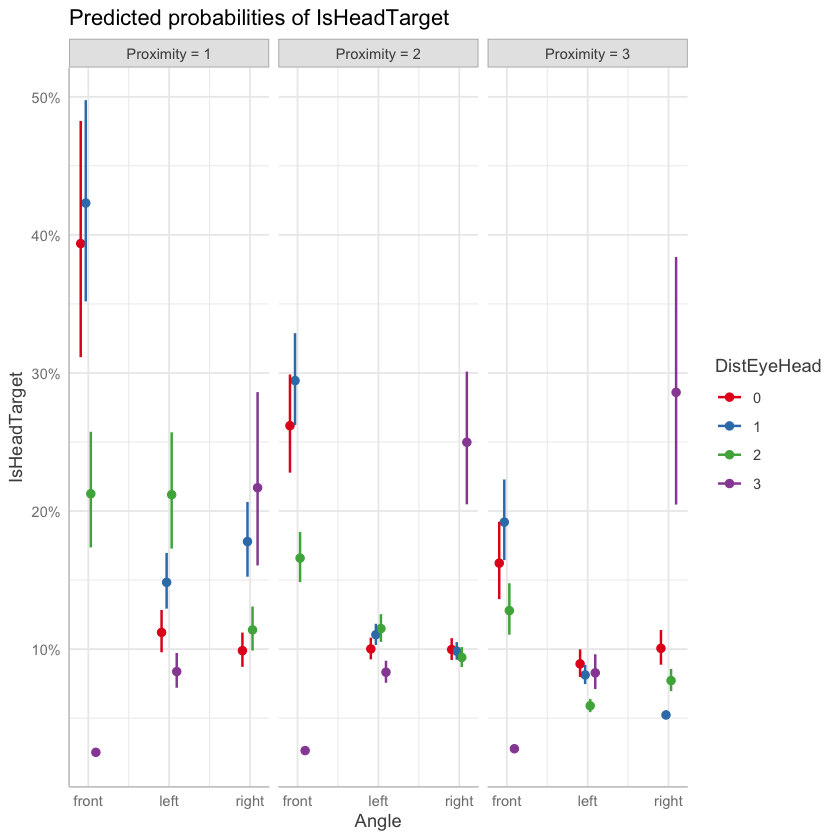

In [ ]:
plot(ggpredict(
  m_4obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

## Exploratory

In [ ]:
df_view <- df_B %>%
  mutate(DistEyeHead = factor(replace_na(DistEyeHead, -1)))

### Prompt Effect

### An Overview

In [ ]:
m_plot <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_B, family = binomial, control = strict_control)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


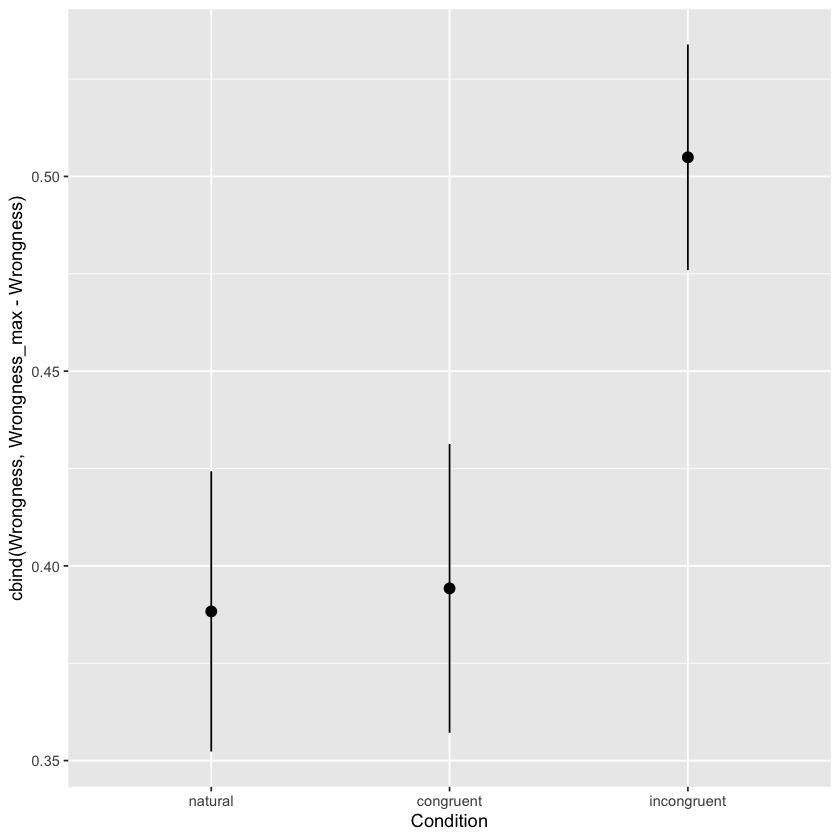

In [ ]:
plot_predictions(m_plot, by = c("Condition"))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning messa

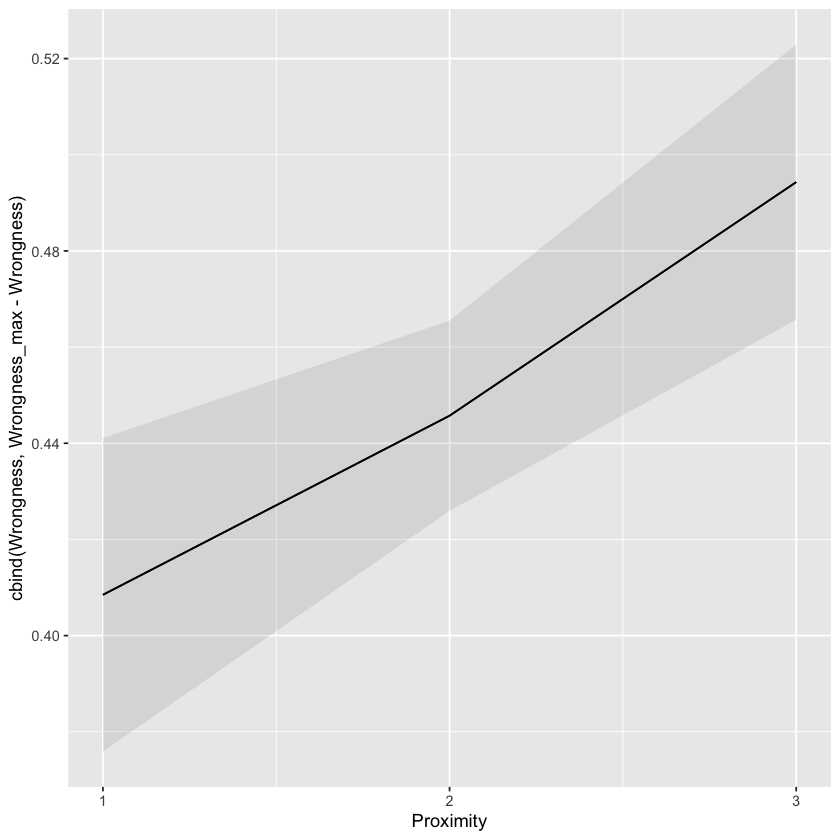

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


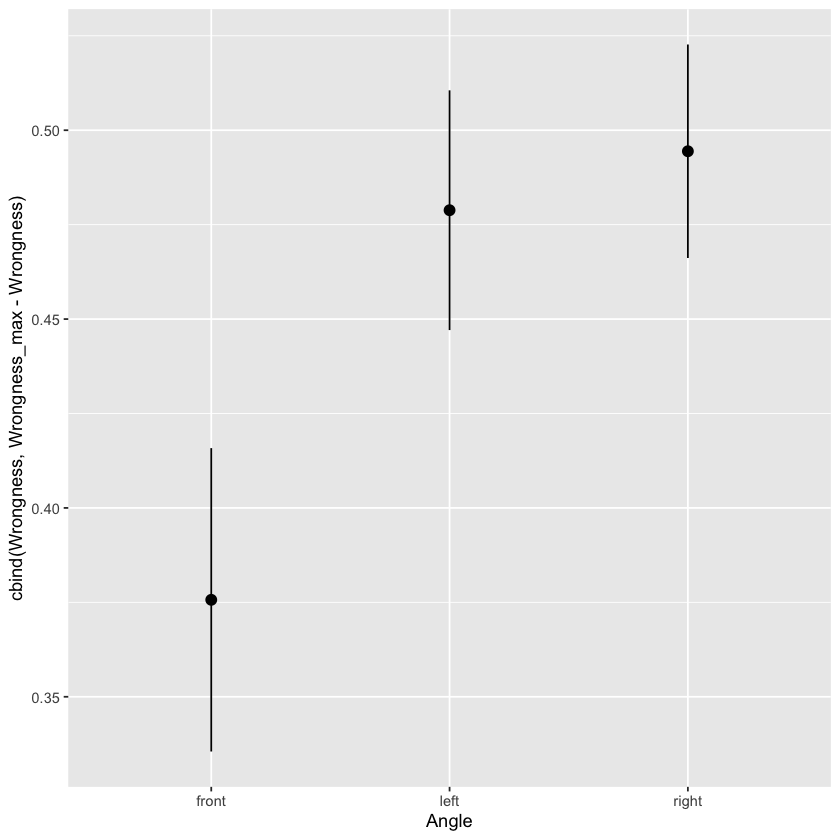

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


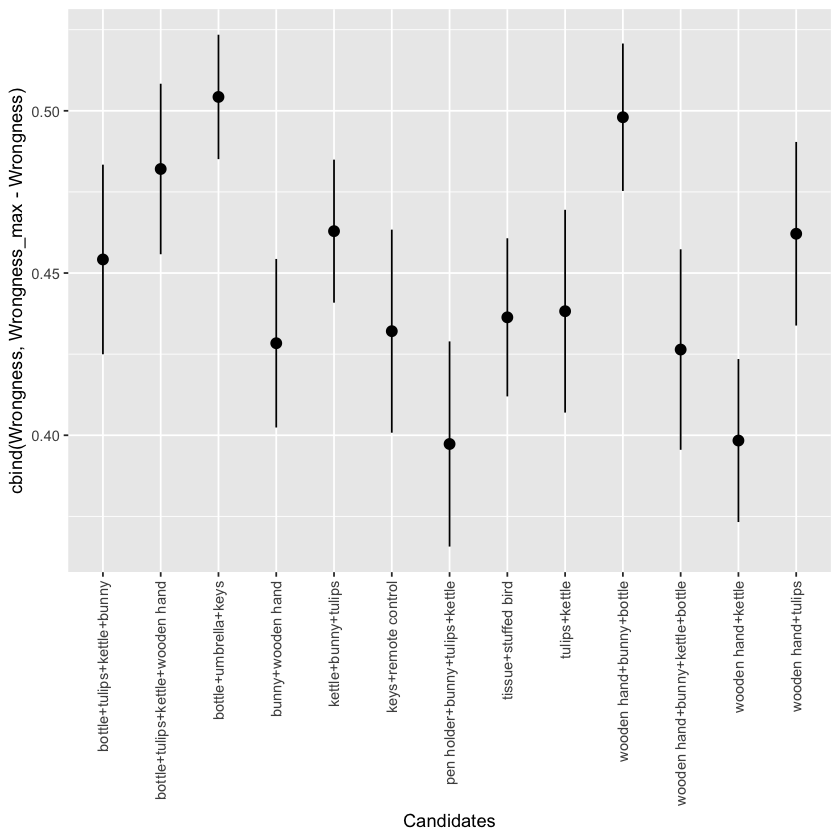

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


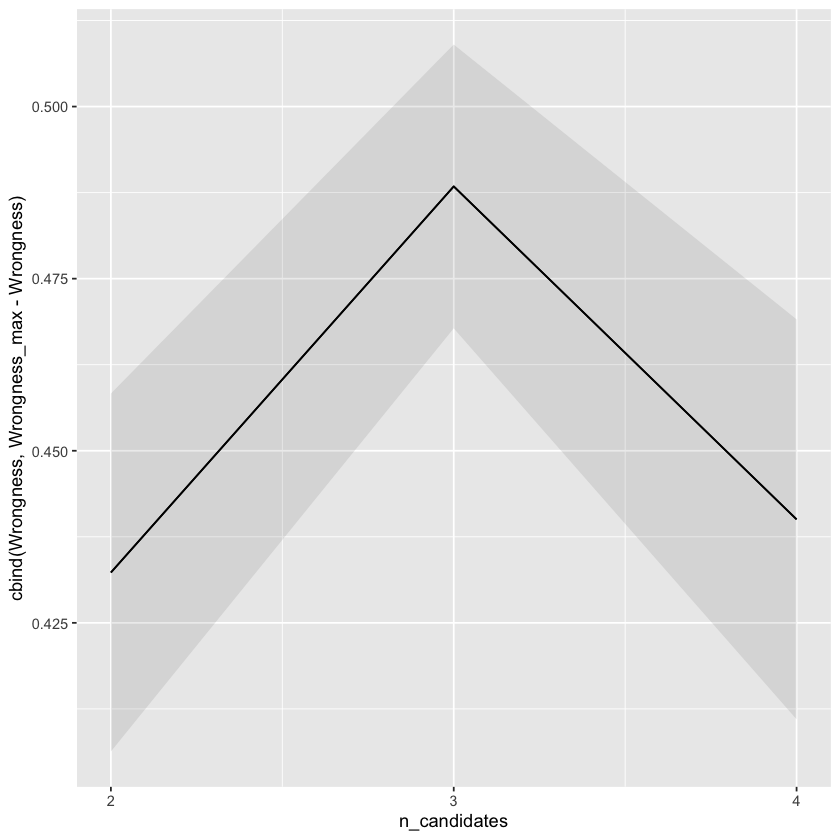

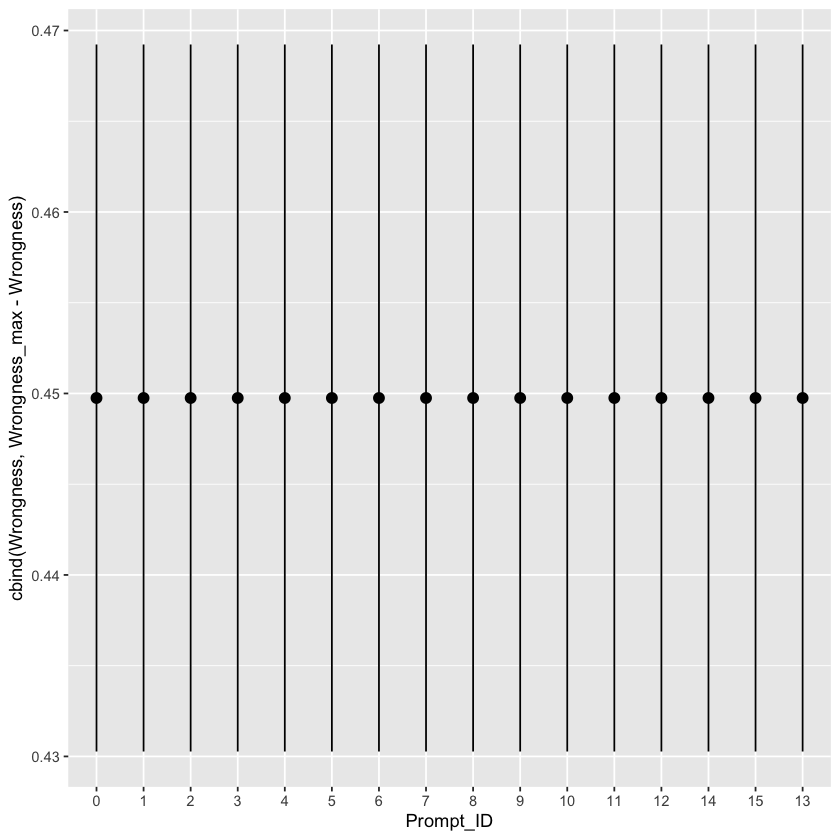

In [ ]:
plot_predictions(m_plot, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))
plot_predictions(m_plot, by = c("Angle"))
plot_predictions(m_plot, by = c("Candidates")) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
plot_predictions(m_plot, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))
plot_predictions(m_plot, by = c("Prompt_ID"))

### Look at View effects in different conditions

In [ ]:
m_prompt <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Prompt_ID * Angle * DistEyeHead * Proximity_c + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

Warning message in commonArgs(par, fn, control, environment()):
“maxfun < 10 * length(par)^2 is not recommended.”


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


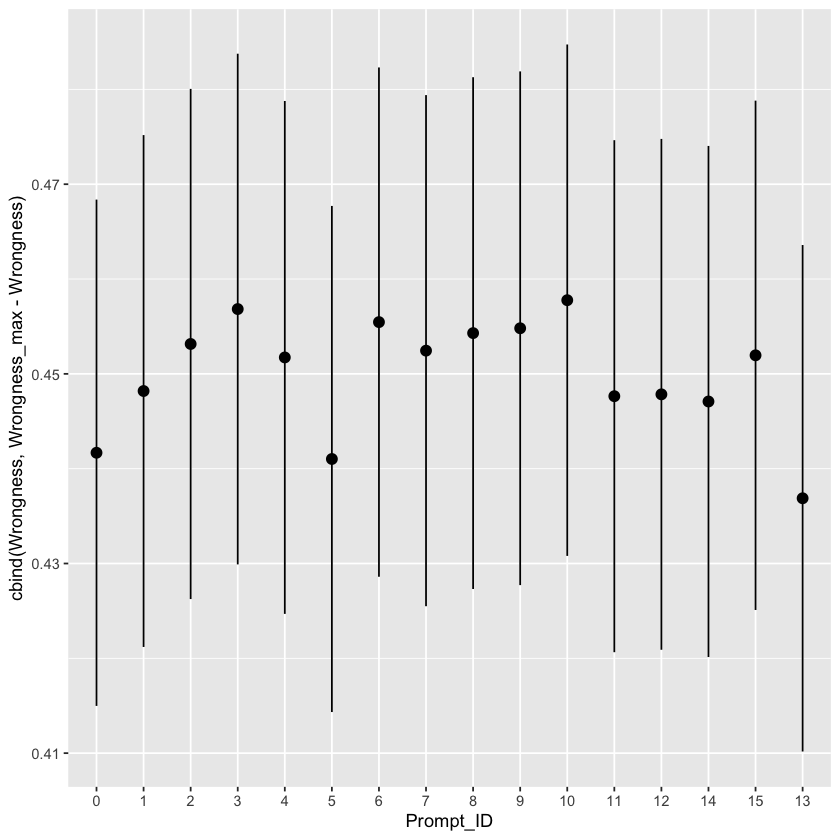

In [ ]:
plot_predictions(m_prompt, by = c("Prompt_ID"))

In [ ]:
model_view_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients



In [ ]:

  
model_view <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

anova(model_view, model_view_c)

In [ ]:
options(repr.plot.width=10, repr.plot.height=6)
plot_slopes(
  model_view_c,
  variables = "Proximity",
  condition = c("DistEyeHead", "n_candidates", "Angle") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

In [ ]:
plot_slopes(
  model_view_c,
  variables = "Angle",
  condition = c("DistEyeHead", "Proximity") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Angle (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

## High resolution

In [53]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Prompt_ID = col_factor()))
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

In [56]:
df1024 <- df[(df$Group == "gpt-5.2-highres") & (df$Stimulus_ID >= 20000), ]
df896 <- df[(df$Group == "gpt-5.2-highres") & (df$Stimulus_ID < 20000), ]
valid_id <- df896$Stimulus_ID[df896$Stimulus_ID < 20000] - 10000
df448 <- df[(df$Group == GROUP_NAME) & (df$Stimulus_ID %in% valid_id), ]

df448$res <- "448x448"
df896$res <- "896x896"
df1024$res <- "1024x1024"

df <- rbind(df448, df896, df1024)
df$res <- factor(df$res, levels = c("448x448", "896x896", "1024x1024"))
df$Condition <- factor(ifelse(is.na(df$DistEyeHead), "Natural", ifelse(df$DistEyeHead == 0, "Congruent", "Incongruent")), levels = c("Natural", "Congruent", "Incongruent"))

In [63]:
df[(df$Group == "gpt-5.2-highres") & (df$Condition == "Natural") & (df$n_candidates == 2), ]$Proximity

[1] 1 1 1 3 2 1 1 1 1 3 2 1

In [58]:
df[(df$Group == "gpt-5.2-highres") & (df$Condition == "Natural") & (df$n_candidates == 3), ]$Accuracy

[1] FALSE  TRUE FALSE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE FALSE  TRUE
[13] FALSE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE

In [ ]:
model <- glmer(
  Accuracy ~ res + scale(n_candidates, scale = FALSE) + Angle + scale(Proximity, scale = FALSE) + Condition + (1 | Stimulus_ID),
  data = df,
  family = binomial,
    control = strict_control
)
summary(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Accuracy ~ res + scale(n_candidates, scale = FALSE) + Angle +  
    scale(Proximity, scale = FALSE) + Condition + (1 | Stimulus_ID)
   Data: df
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  1406.9   1461.9   -693.5   1386.9     1790 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.7518 -0.2596 -0.1013  0.2823  4.0766 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 13.6     3.687   
Number of obs: 1800, groups:  Stimulus_ID, 300

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                         -1.1468     0.7169  -1.600   0.1097    
res896x896                          -0.7716     0.6818  -1.132   0.2578    
res1024x1024                        -0.1432     0.6785  -0.211   0.8328    
scale(n_candidates, scale = FALSE) 

In [40]:
avg_predictions(model, variables = "res") %>%
  select(res, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

res,estimate,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>
448x448,0.387,0.308,0.465
896x896,0.318,0.218,0.419
1024x1024,0.374,0.273,0.476


In [45]:
avg_predictions(model, variables = c("res", "Proximity")) %>%
  select(res, Proximity, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

res,Proximity,estimate,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
448x448,1,0.430,0.324,0.536
448x448,2,0.394,0.314,0.474
448x448,3,0.358,0.261,0.455
896x896,1,0.359,0.237,0.481
896x896,2,0.324,0.221,0.427
896x896,3,0.289,0.173,0.406
1024x1024,1,0.417,0.294,0.539
1024x1024,2,0.381,0.278,0.484
1024x1024,3,0.345,0.227,0.464


In [44]:
avg_predictions(model, variables = c("res", "Condition")) %>%
  select(res, Condition, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

res,Condition,estimate,conf.low,conf.high
<fct>,<fct>,<dbl>,<dbl>,<dbl>
448x448,Natural,0.470,0.350,0.591
448x448,Congruent,0.398,0.281,0.515
448x448,Incongruent,0.352,0.253,0.450
896x896,Natural,0.399,0.263,0.535
896x896,Congruent,0.326,0.188,0.463
896x896,Incongruent,0.280,0.163,0.398
1024x1024,Natural,0.457,0.322,0.592
1024x1024,Congruent,0.385,0.247,0.522
1024x1024,Incongruent,0.338,0.220,0.457


In [46]:
avg_predictions(model, variables = c("res", "n_candidates")) %>%
  select(res, n_candidates, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

res,n_candidates,estimate,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
448x448,2,0.626,0.485,0.767
448x448,3,0.431,0.344,0.518
448x448,4,0.261,0.164,0.359
896x896,2,0.540,0.382,0.699
896x896,3,0.355,0.247,0.463
896x896,4,0.195,0.085,0.305
1024x1024,2,0.610,0.448,0.772
1024x1024,3,0.417,0.305,0.529
1024x1024,4,0.249,0.134,0.363


In [59]:
avg_predictions(model, variables = c("res", "Angle")) %>%
  select(res, Angle, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

res,Angle,estimate,conf.low,conf.high
<fct>,<chr>,<dbl>,<dbl>,<dbl>
448x448,front,0.334,0.231,0.438
448x448,left,0.355,0.247,0.464
448x448,right,0.499,0.391,0.608
896x896,front,0.266,0.144,0.387
896x896,left,0.286,0.161,0.412
896x896,right,0.430,0.307,0.553
1024x1024,front,0.322,0.198,0.445
1024x1024,left,0.342,0.217,0.468
1024x1024,right,0.487,0.362,0.611


In [65]:
m1 <- glm(Accuracy ~ res * Condition, data = df, family = binomial)
avg_predictions(m1, variables = c("Condition", "res")) %>%
  select(Condition, res, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

Condition,res,estimate,conf.low,conf.high
<fct>,<fct>,<dbl>,<dbl>,<dbl>
Natural,448x448,0.472,0.424,0.521
Natural,896x896,0.440,0.245,0.635
Natural,1024x1024,0.440,0.245,0.635
Congruent,448x448,0.407,0.361,0.454
Congruent,896x896,0.407,0.222,0.593
Congruent,1024x1024,0.407,0.222,0.593
Incongruent,448x448,0.337,0.304,0.371
Incongruent,896x896,0.250,0.128,0.372
Incongruent,1024x1024,0.354,0.219,0.489


In [81]:
m0 <- glm(Accuracy ~ res, data = df, family = binomial)
avg_predictions(m0, variables = "res") %>%
  select(res, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))
avg_predictions(m0, variables = "res", hypothesis = ~ pairwise)

res,estimate,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>
448x448,0.39,0.366,0.414
896x896,0.34,0.247,0.433
1024x1024,0.39,0.294,0.486


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(896x896) - (448x448),-0.05,0.04891510,-1.0221792,0.3066961,1.705118,-0.14587183,0.04587183
(1024x1024) - (448x448),0.00,0.05027581,0.0000000,1.0000000,0.000000,-0.09853878,0.09853878
(1024x1024) - (896x896),0.05,0.06799244,0.7353759,0.4621106,1.113690,-0.08326272,0.18326272


In [72]:
df[(df$res == "896x896") & (df$Condition == "Congruent"), ]$Accuracy

[1]  TRUE FALSE  TRUE FALSE  TRUE FALSE FALSE  TRUE  TRUE  TRUE FALSE  TRUE
[13]  TRUE FALSE  TRUE FALSE FALSE  TRUE FALSE  TRUE FALSE FALSE FALSE FALSE
[25] FALSE FALSE FALSE

In [70]:
df[(df$res == "1024x1024") & (df$Condition == "Congruent"), ]$Accuracy

[1] FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE  TRUE  TRUE FALSE  TRUE
[13]  TRUE FALSE  TRUE  TRUE FALSE  TRUE FALSE  TRUE FALSE FALSE FALSE  TRUE
[25]  TRUE FALSE FALSE